# A two-sector I-HANK model with Present Bias

**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
- 2. [Fixed exchange rate regime](#toc2_)    
  - 2.1. [Model with exponential discounting](#toc2_1_)    
    - 2.1.1. [Steady State](#toc2_1_1_)    
    - 2.1.2. [MPC](#toc2_1_2_)    
    - 2.1.3. [Policy functions](#toc2_1_3_)    
    - 2.1.4. [Compute Jacobians](#toc2_1_4_)    
    - 2.1.5. [Government spending shock](#toc2_1_5_)    
  - 2.2. [Model with present biased](#toc2_2_)    
    - 2.2.1. [Steady State](#toc2_2_1_)    
    - 2.2.2. [MPC](#toc2_2_2_)    
    - 2.2.3. [Policy functions](#toc2_2_3_)    
- 3. [Foreign demand shock](#toc3_)    
- 4. [Response in consumption Goverment Spending Shock](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [74]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt   
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from IHANKModel import IHANKModelClass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [75]:
model = IHANKModelClass(name='baseline')

In [76]:
model.info()

settings:
 par.py_hh = False
 par.py_blocks = False
 par.full_z_trans = False
 par.warnings = True
 par.T = 500

households:
 grids_hh: [a]
 pols_hh: [a]
 inputs_hh: [beta,ra,inc_TH,inc_NT]
 inputs_hh_z: []
 outputs_hh: [a,c,uc_TH,uc_NT,c_TH,c_NT]
 intertemps_hh: [vbeg_a]

aggregate:
 shocks: [ZTH,ZNT,M_s,rF,PF_s,beta,G,i_shock]
 unknowns: [CB,NNT,NTH,piWTH,piWNT]
 targets: [NKWCT_res,NKWCNT_res,clearing_YTH,clearing_YNT,UIP_res]

blocks (inputs -> outputs):
 mon_pol: [CB] -> [E]
 production: [ZTH,ZNT,NTH,NNT,piWTH,piWNT] -> [YTH,YNT,WTH,WNT,PTH,PNT]
 prices: [PF_s,E,PTH,PNT,WTH,WNT] -> [PF,PTH_s,PT,P,Q,wTH,wNT]
 inflation: [PF_s,PF,PNT,PTH,PT,P,PTH_s] -> [pi_F_s,pi_F,pi_NT,pi_TH,pi_T,pi,pi_TH_s]
 central_bank: [pi,E,i_shock,CB] -> [i,r,ra]
 government: [PNT,P,wTH,NTH,wNT,NNT,ra,G] -> [B,tau,inc_TH,inc_NT]
 hh: [beta,inc_NT,inc_TH,ra] -> [A_hh,C_hh,UC_TH_hh,UC_NT_hh,C_TH_hh,C_NT_hh]
 NKWCs: [beta,piWTH,piWNT,NTH,NNT,wTH,wNT,tau,UC_TH_hh,UC_NT_hh] -> [NKWCT_res,NKWCNT_res]
 UIP: [Q,r,rF

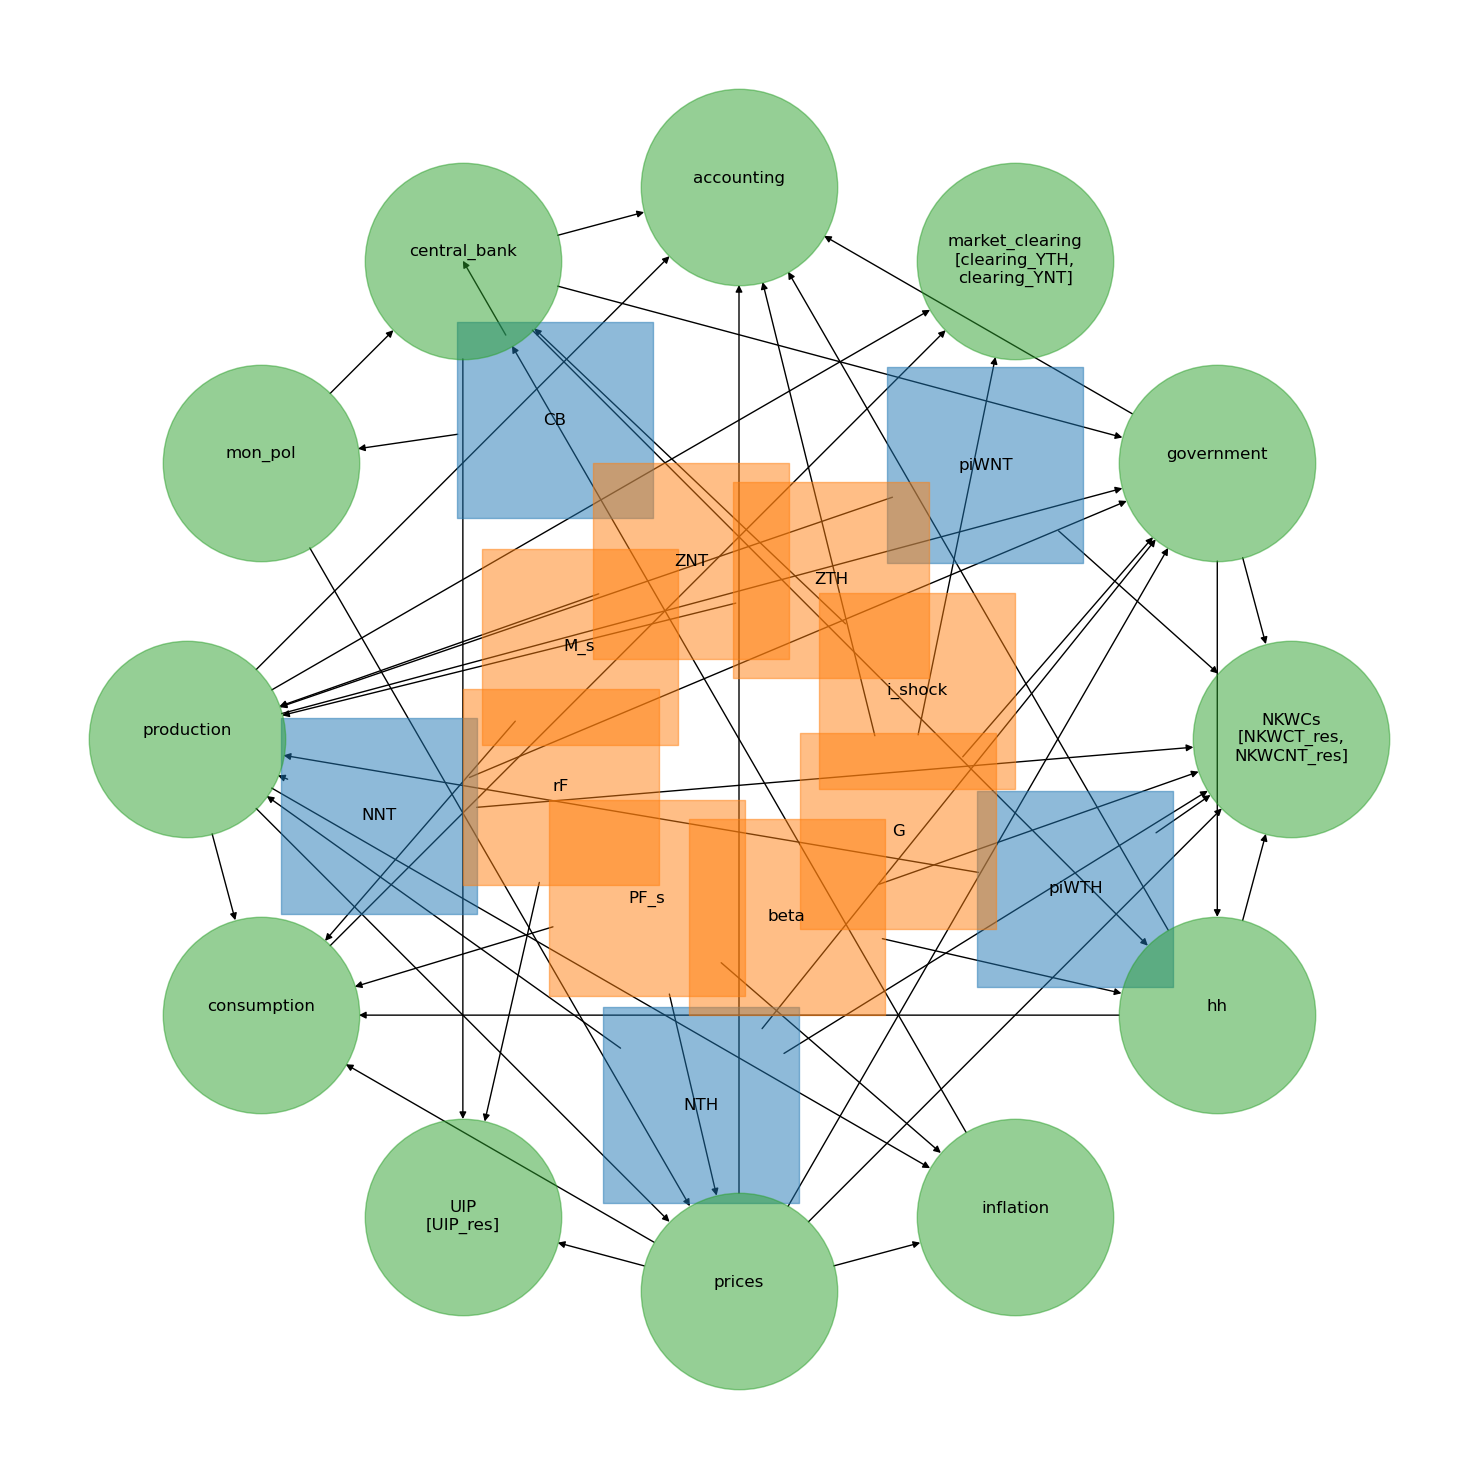

In [77]:
model.draw_DAG(figsize=(15,15),order=['shocks','unknowns','blocks'])

In [78]:
par = model.par
ss = model.ss
path = model.path
sim = model.sim

## 2. <a id='toc2_'></a>[Fixed exchange rate regime](#toc0_)

### 2.1. <a id='toc2_1_'></a>[Model with exponential discounting](#toc0_)

In [79]:
ExpoDisc = model.copy()
ExpoDisc.par.delta = 1.0

#### 2.1.1. <a id='toc2_1_1_'></a>[Steady State](#toc0_)

In [80]:
ExpoDisc.find_ss(do_print=True)

household problem in ss solved in 1.2 secs [375 iterations]
household problem in ss simulated in 0.2 secs [406 iterations]
steady state found in 1.4 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.355
par.alphaF = 0.333
par.varphiTH = 1.271
par.varphiNT = 1.271
ss.M_s = 0.083
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =  -0.00000000
ss.G = 0.296
ss.NFA = 0.000


In [81]:
ExpoDisc.test_ss()

E              :       1.0000
CB             :       0.0050
ZTH            :       1.0000
ZNT            :       1.0000
NTH            :       0.2500
NNT            :       0.7500
piWTH          :       0.0000
piWNT          :       0.0000
YTH            :       0.2500
YNT            :       0.7500
WTH            :       1.0000
WNT            :       1.0000
PTH            :       1.0000
PNT            :       1.0000
PF_s           :       1.0000
PF             :       1.0000
PTH_s          :       1.0000
PT             :       1.0000
P              :       1.0000
Q              :       1.0000
wTH            :       1.0000
wNT            :       1.0000
pi_F_s         :       0.0000
pi_F           :       0.0000
pi_NT          :       0.0000
pi_TH          :       0.0000
pi_T           :       0.0000
pi             :       0.0000
pi_TH_s        :       0.0000
i              :       0.0050
r              :       0.0050
ra             :       0.0050
i_shock        :       0.0000
G         

#### 2.1.2. <a id='toc2_1_2_'></a>[MPC](#toc0_)

In [82]:
MPCExpoDisc = np.sum(ExpoDisc.ss.D[:,:,:-1]*(ExpoDisc.ss.c[:,:,1:]-ExpoDisc.ss.c[:,:,:-1])/((1+ExpoDisc.ss.r)*(ExpoDisc.par.a_grid[1:]-ExpoDisc.par.a_grid[:-1])))
print("MPC under exponential discounting",MPCExpoDisc)

MPC under exponential discounting 0.31555478861639585


#### 2.1.3. <a id='toc2_1_3_'></a>[Policy functions](#toc0_)

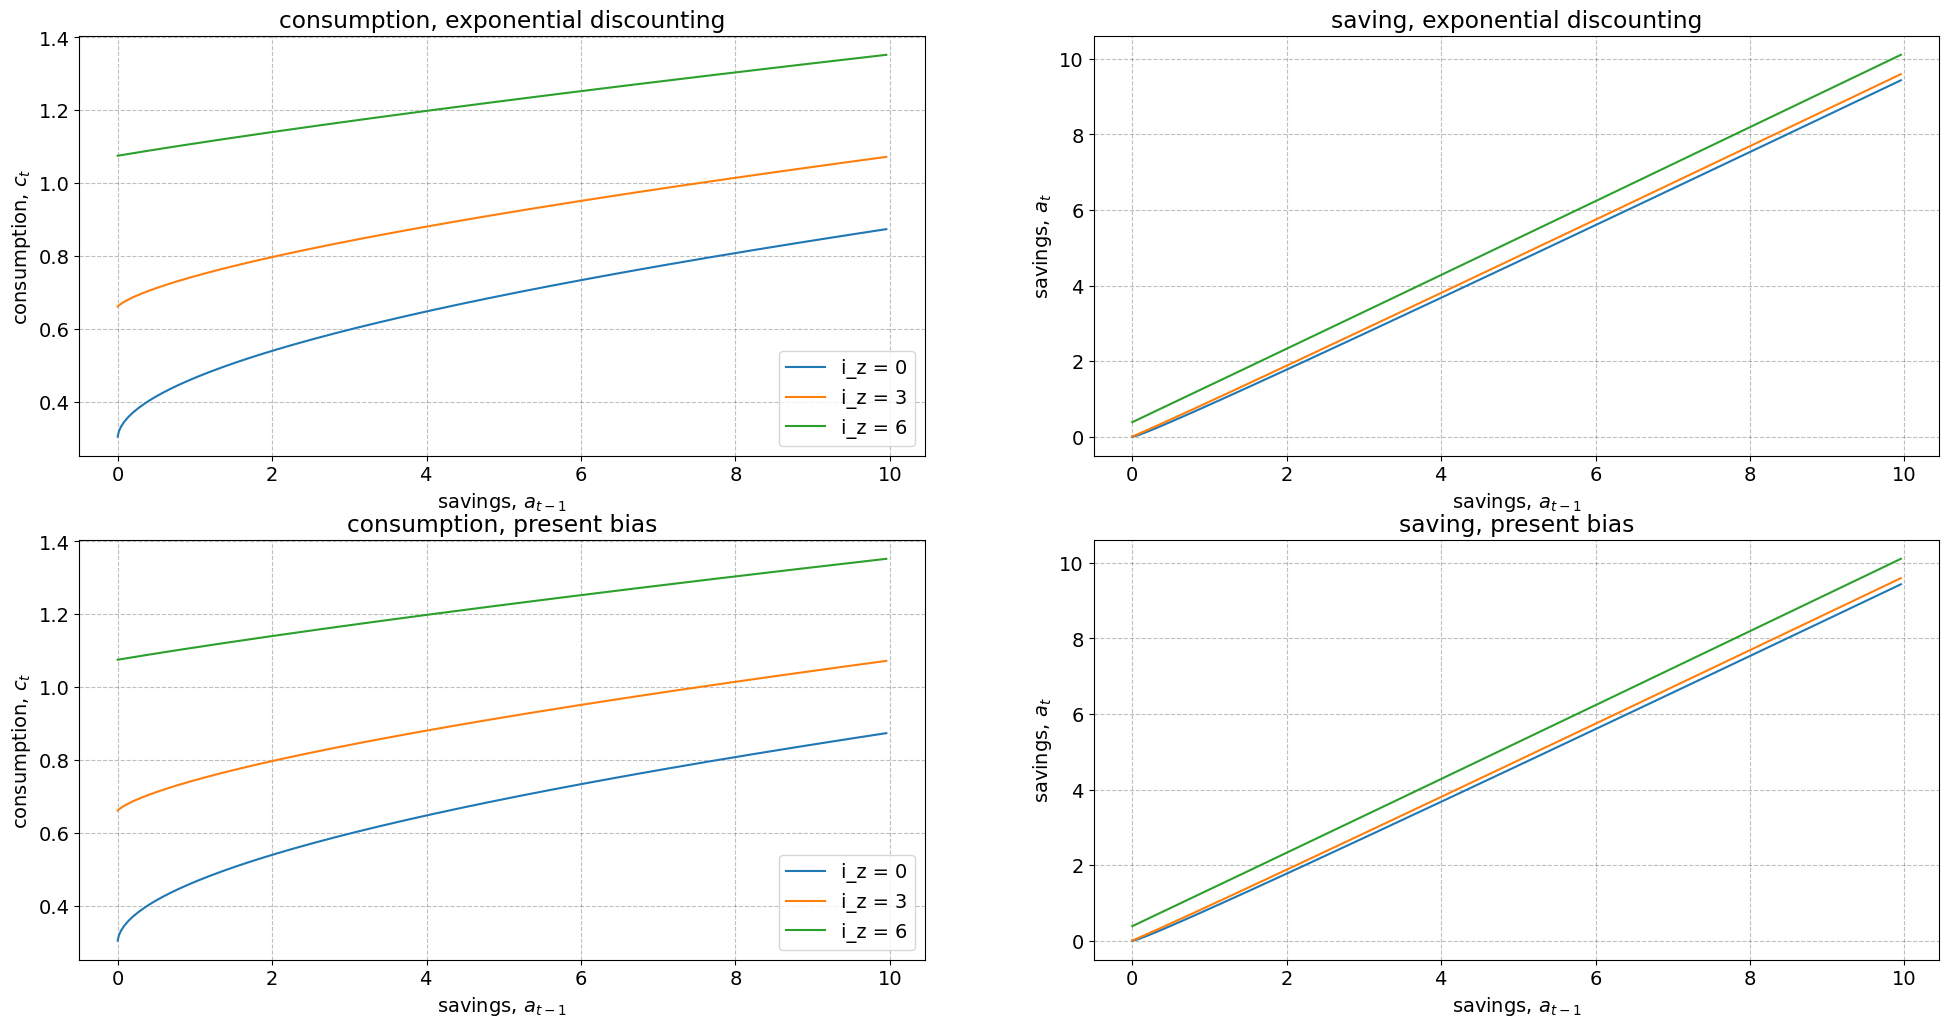

In [83]:
fig = plt.figure(figsize=(24,12),dpi=100)
a_max = 10

# a. consumption, without present bias
I = ExpoDisc.par.a_grid < a_max

ax = fig.add_subplot(2,2,1)
ax.set_title(f'consumption, exponential discounting')


for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(ExpoDisc.par.a_grid[I],ExpoDisc.ss.c[0,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# b. saving, without present bias
I = ExpoDisc.par.a_grid < a_max

ax = fig.add_subplot(2,2,2)
ax.set_title(f'saving, exponential discounting')

for i_z in [0,ExpoDisc.par.Nz//2,ExpoDisc.par.Nz-1]:
    ax.plot(ExpoDisc.par.a_grid[I],ExpoDisc.ss.a[0,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')

# c. consumption, with present bias
I = ExpoDisc.par.a_grid < a_max

ax = fig.add_subplot(2,2,3)
ax.set_title(f'consumption, present bias')

for i_z in [0,ExpoDisc.par.Nz//2,ExpoDisc.par.Nz-1]:
    ax.plot(ExpoDisc.par.a_grid[I],ExpoDisc.ss.c[1,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# d. saving, with present bias
I = ExpoDisc.par.a_grid < a_max

ax = fig.add_subplot(2,2,4)
ax.set_title(f'saving, present bias')

for i_z in [0,ExpoDisc.par.Nz//2,par.Nz-1]:
    ax.plot(ExpoDisc.par.a_grid[I],ExpoDisc.ss.a[1,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')


plt.show()

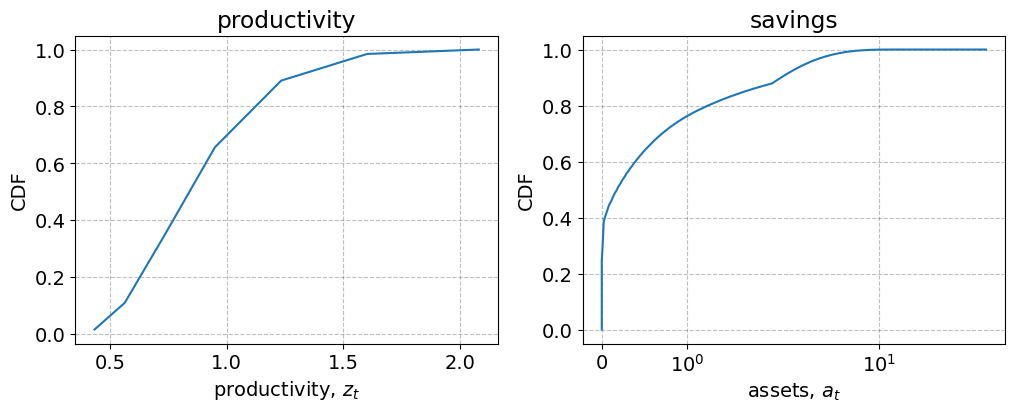

In [84]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

y = np.cumsum(np.sum(ExpoDisc.ss.D[0],axis=1))
ax.plot(ExpoDisc.par.z_grid,y/y[-1])

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('CDF')

# b. assets
ax = fig.add_subplot(1,2,2)
ax.set_title('savings')
y = np.insert(np.cumsum(np.sum(ExpoDisc.ss.D[0],axis=0)),0,0.0)
ax.plot(np.insert(ExpoDisc.par.a_grid,0,ExpoDisc.par.a_grid[0]),y/y[-1])
        
ax.set_xlabel('assets, $a_{t}$')
ax.set_ylabel('CDF')
ax.set_xscale('symlog')

#### 2.1.4. <a id='toc2_1_4_'></a>[Compute Jacobians](#toc0_)

**Household transition path:**

note: inputs = steady state value -> expected: constant value (straigt line)

household problem solved along transition path in 2.2 secs
household problem simulated along transition in 0.6 secs



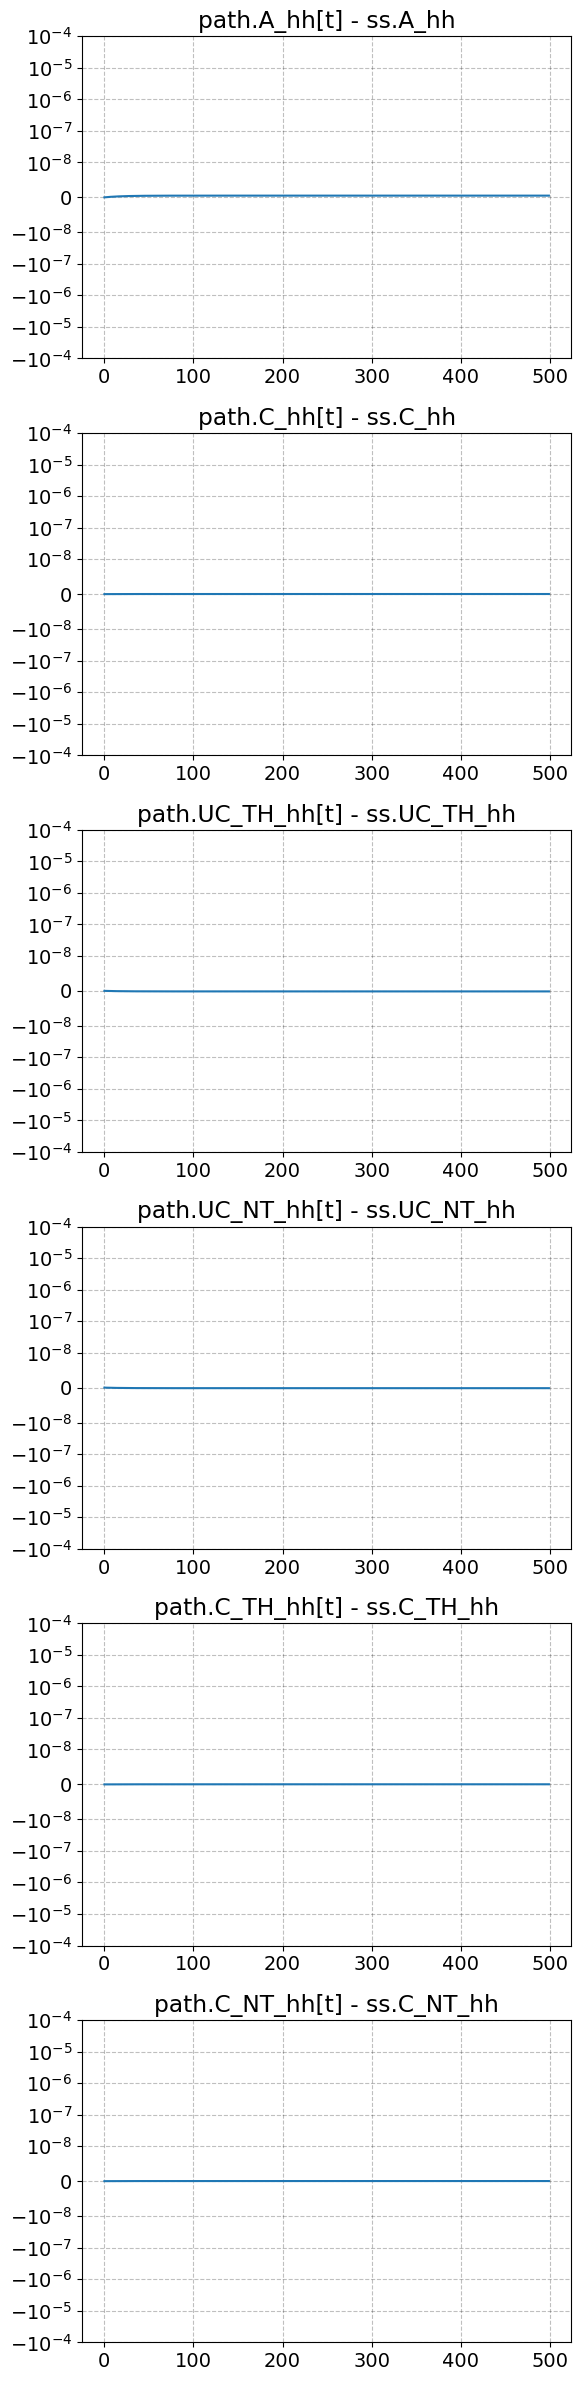

In [85]:
ExpoDisc.test_hh_path()

**Full transition path:**

In [86]:
ExpoDisc.test_path()

shocks: ZTH ZNT M_s rF PF_s beta G i_shock 
unknowns: CB NNT NTH piWTH piWNT 

blocks.mon_pol
 E                0.0e+00
blocks.production
 YTH              0.0e+00
 YNT              0.0e+00
 WTH              0.0e+00
 WNT              0.0e+00
 PTH              0.0e+00
 PNT              0.0e+00
blocks.prices
 PF               0.0e+00
 PTH_s            0.0e+00
 PT               0.0e+00
 P                0.0e+00
 Q                0.0e+00
 wTH              0.0e+00
 wNT              0.0e+00
blocks.inflation
 pi_F_s           0.0e+00
 pi_F             0.0e+00
 pi_NT            0.0e+00
 pi_TH            0.0e+00
 pi_T             0.0e+00
 pi               0.0e+00
 pi_TH_s          0.0e+00
blocks.central_bank
 i                0.0e+00
 r                1.1e-16
 ra               1.1e-16
blocks.government
 B                5.6e-16
 tau              5.6e-17
 inc_TH           2.8e-17
 inc_NT           1.1e-16
hh
 A_hh             4.9e-10
 C_hh             2.9e-11
 UC_TH_hh         1.5e-10
 UC_NT_hh 

**Jacobians:**

In [87]:
ExpoDisc.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 2.3 secs
curly_Y and curly_D calculated for inc_NT          in 2.2 secs
curly_Y and curly_D calculated for inc_TH          in 2.4 secs
curly_Y and curly_D calculated for ra              in 2.2 secs
curly_E calculated in 1.0 secs
builiding blocks combined in 3.4 secs
household Jacobian computed in 13.6 secs

full Jacobians:
full Jacobian to unknowns computed in 3.7 secs [in evaluate_blocks(): 1.7 secs]
full Jacobian to shocks computed in 6.0 secs [in evaluate_blocks(): 2.7 secs]


#### 2.1.5. <a id='toc2_1_5_'></a>[Government spending shock](#toc0_)

In [88]:
ExpoDisc.par.jump_G = -0.025
ExpoDisc.par.rho_G = 0.80 # AR(1) coefficeint

ExpoDisc.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

finding the transition path:
 it =   0 -> max. abs. error = 2.30e-02
   8.84e-04 in NKWCT_res
   8.84e-04 in NKWCNT_res
   1.07e-03 in clearing_YTH
   2.30e-02 in clearing_YNT
   0.00e+00 in UIP_res
 it =   1 -> max. abs. error = 4.43e-04
   2.01e-05 in NKWCT_res
   4.43e-04 in NKWCNT_res
   1.19e-04 in clearing_YTH
   3.22e-04 in clearing_YNT
   9.86e-05 in UIP_res
 it =   2 -> max. abs. error = 1.10e-05
   3.16e-06 in NKWCT_res
   1.10e-05 in NKWCNT_res
   5.93e-06 in clearing_YTH
   1.08e-05 in clearing_YNT
   7.91e-06 in UIP_res
 it =   3 -> max. abs. error = 2.42e-07
   3.16e-08 in NKWCT_res
   1.88e-07 in NKWCNT_res
   7.44e-08 in clearing_YTH
   2.42e-07 in clearing_YNT
   4.49e-08 in UIP_res
 it =   4 -> max. abs. error = 6.06e-09
   8.94e-10 in NKWCT_res
   6.06e-09 in NKWCNT_res
   1.89e-09 in clearing_YTH
   6.04e-09 in clearing_YNT
   6.13e-10 in UIP_res
 it =   5 -> max. abs. error = 3.58e-10
   3.56e-11 in NKWCT_res
   3.27e-10 in NKWCNT_res
   1.26e-10 in clearing_YTH
  

### shocks ###


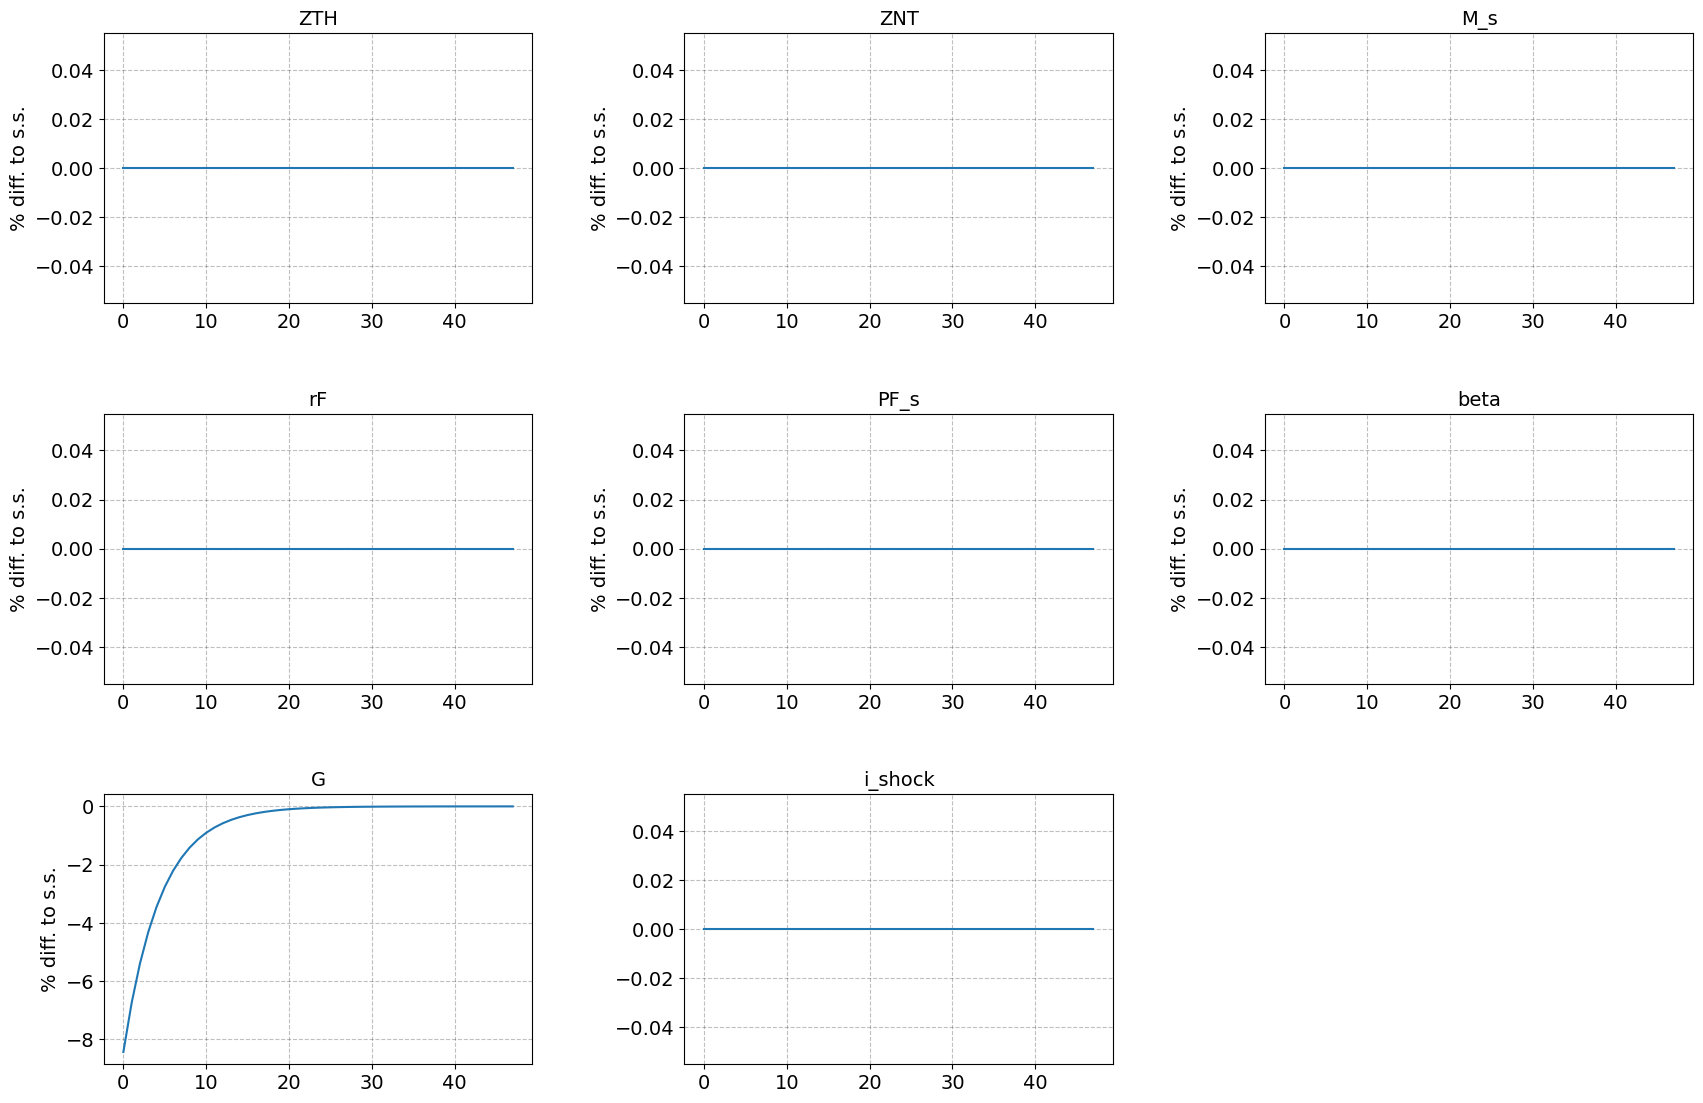


### varnames ###


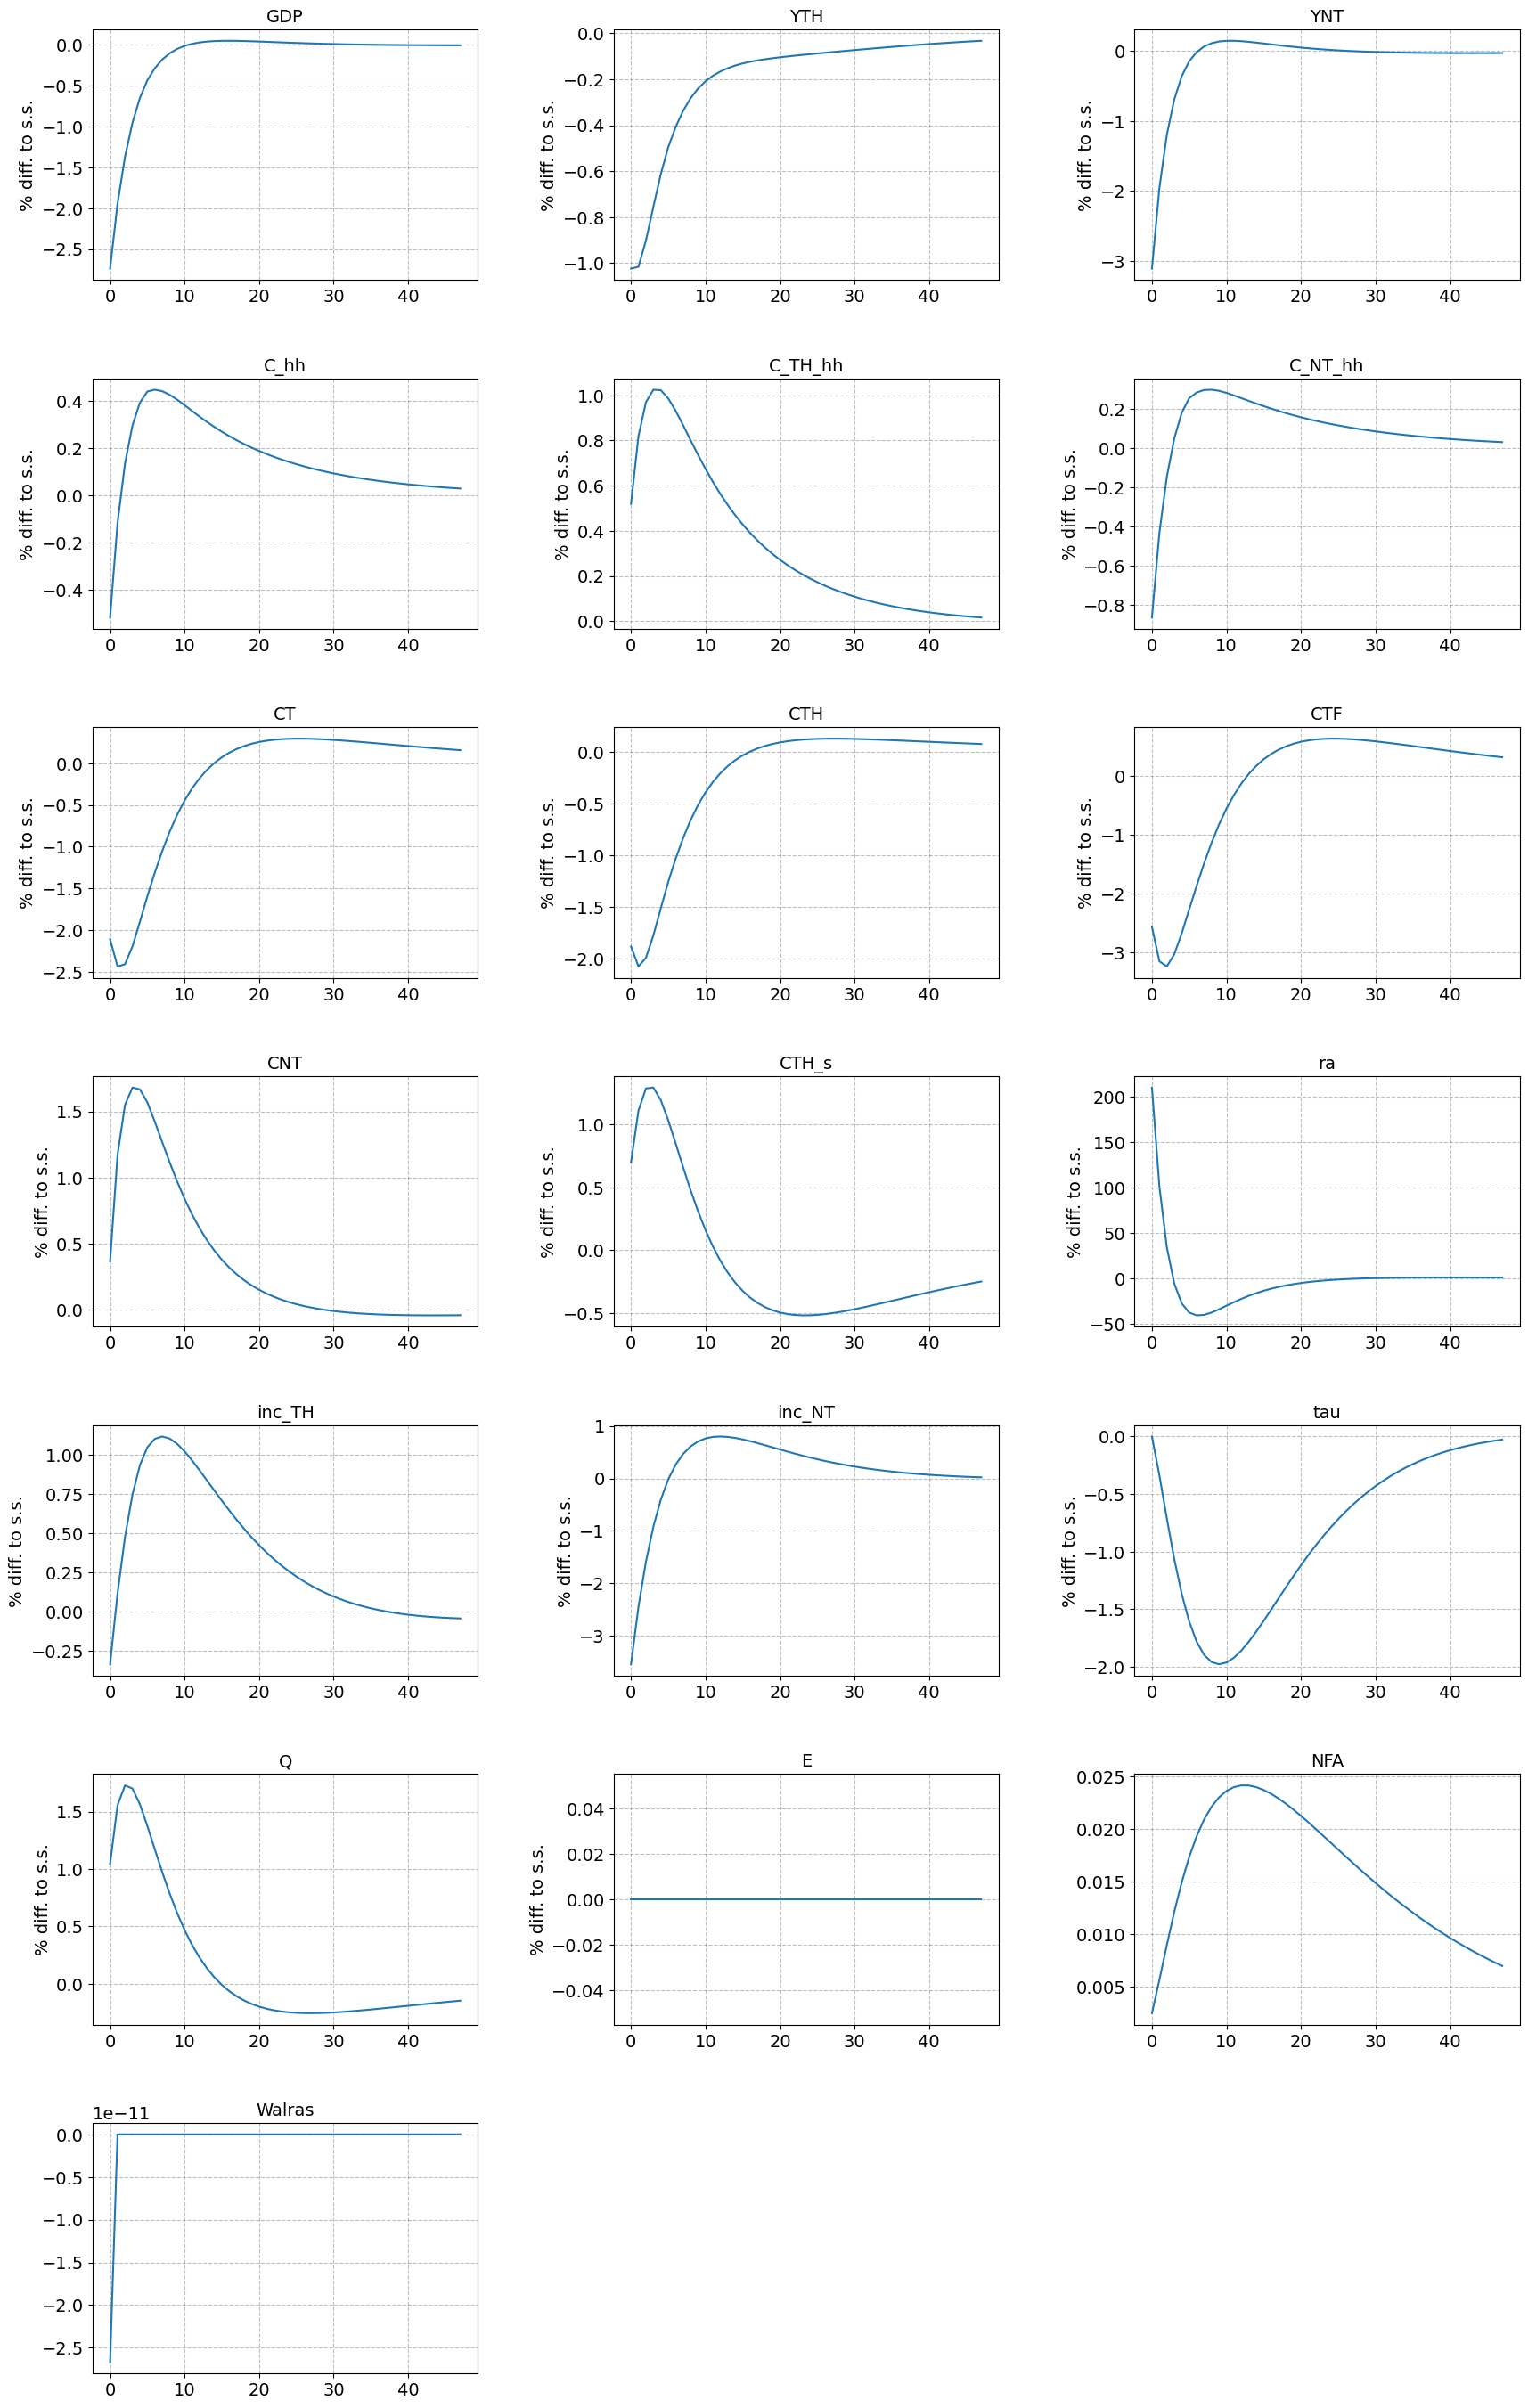


### tagets ###


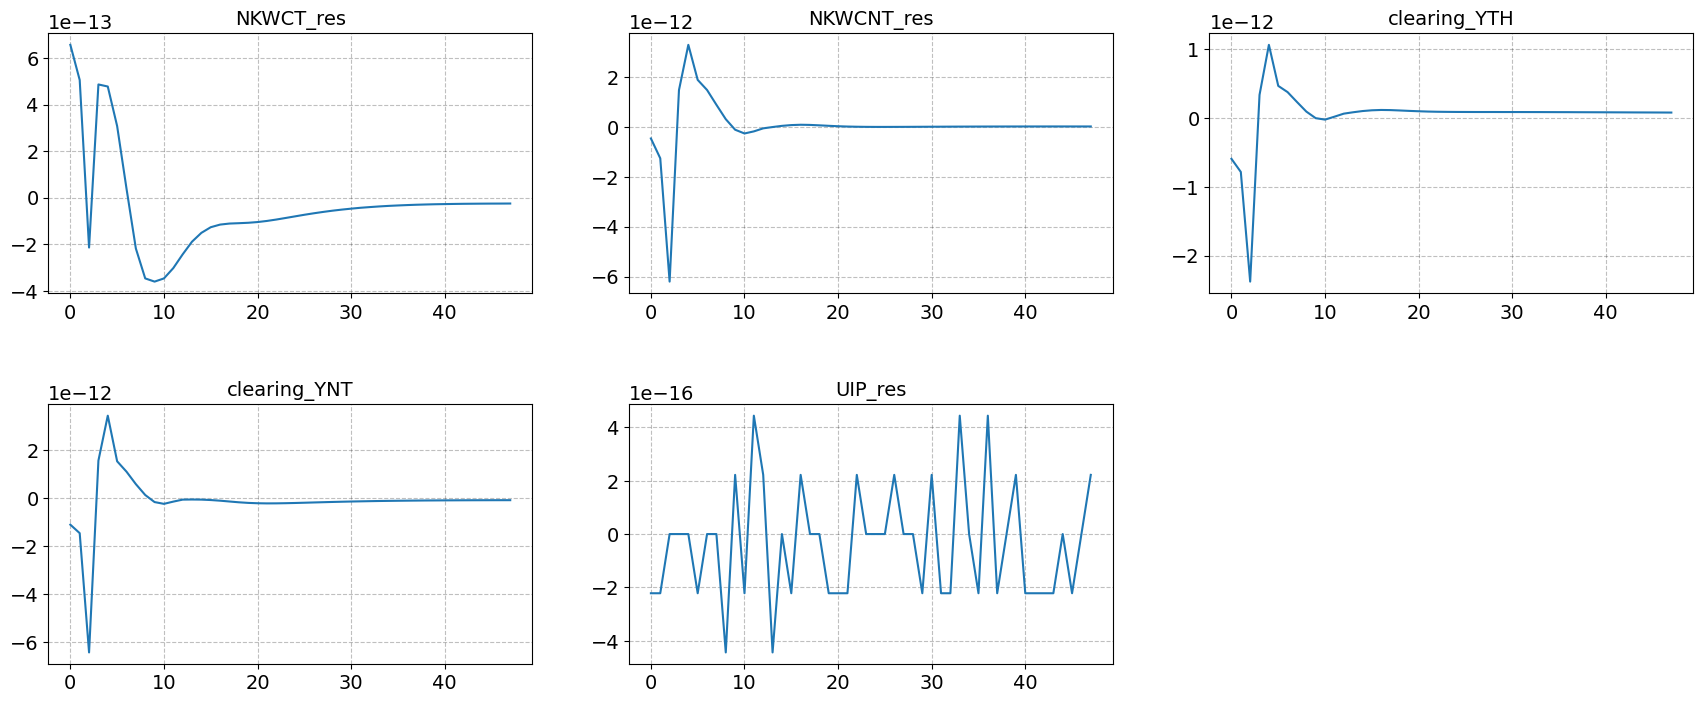

In [89]:
paths = ['GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock']
ExpoDisc.show_IRFs(paths,lvl_value=lvl_value,T_max=48,ncols=3)

### 2.2. <a id='toc2_2_'></a>[Model with present biased](#toc0_)

In [90]:
PB = model.copy()
PB.par.delta = 0.6

#### 2.2.1. <a id='toc2_2_1_'></a>[Steady State](#toc0_)

In [91]:
PB.find_ss(do_print=True)

household problem in ss solved in 1.3 secs [377 iterations]
household problem in ss simulated in 0.1 secs [406 iterations]
steady state found in 1.4 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.356
par.alphaF = 0.333
par.varphiTH = 1.295
par.varphiNT = 1.295
ss.M_s = 0.083
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.298
ss.NFA = 0.000


In [92]:
PB.test_ss()

E              :       1.0000
CB             :       0.0050
ZTH            :       1.0000
ZNT            :       1.0000
NTH            :       0.2500
NNT            :       0.7500
piWTH          :       0.0000
piWNT          :       0.0000
YTH            :       0.2500
YNT            :       0.7500
WTH            :       1.0000
WNT            :       1.0000
PTH            :       1.0000
PNT            :       1.0000
PF_s           :       1.0000
PF             :       1.0000
PTH_s          :       1.0000
PT             :       1.0000
P              :       1.0000
Q              :       1.0000
wTH            :       1.0000
wNT            :       1.0000
pi_F_s         :       0.0000
pi_F           :       0.0000
pi_NT          :       0.0000
pi_TH          :       0.0000
pi_T           :       0.0000
pi             :       0.0000
pi_TH_s        :       0.0000
i              :       0.0050
r              :       0.0050
ra             :       0.0050
i_shock        :       0.0000
G         

#### 2.2.2. <a id='toc2_2_2_'></a>[MPC](#toc0_)

In [93]:
MPC_PB = np.sum(PB.ss.D[:,:,:-1]*(PB.ss.c[:,:,1:]-PB.ss.c[:,:,:-1])/((1+PB.ss.r)*(PB.par.a_grid[1:]-PB.par.a_grid[:-1])))
print("MPC under Present bias \delta =0.6 is",MPC_PB)

MPC under Present bias \delta =0.6 is 0.6463645632142196


#### 2.2.3. <a id='toc2_2_3_'></a>[Policy functions](#toc0_)

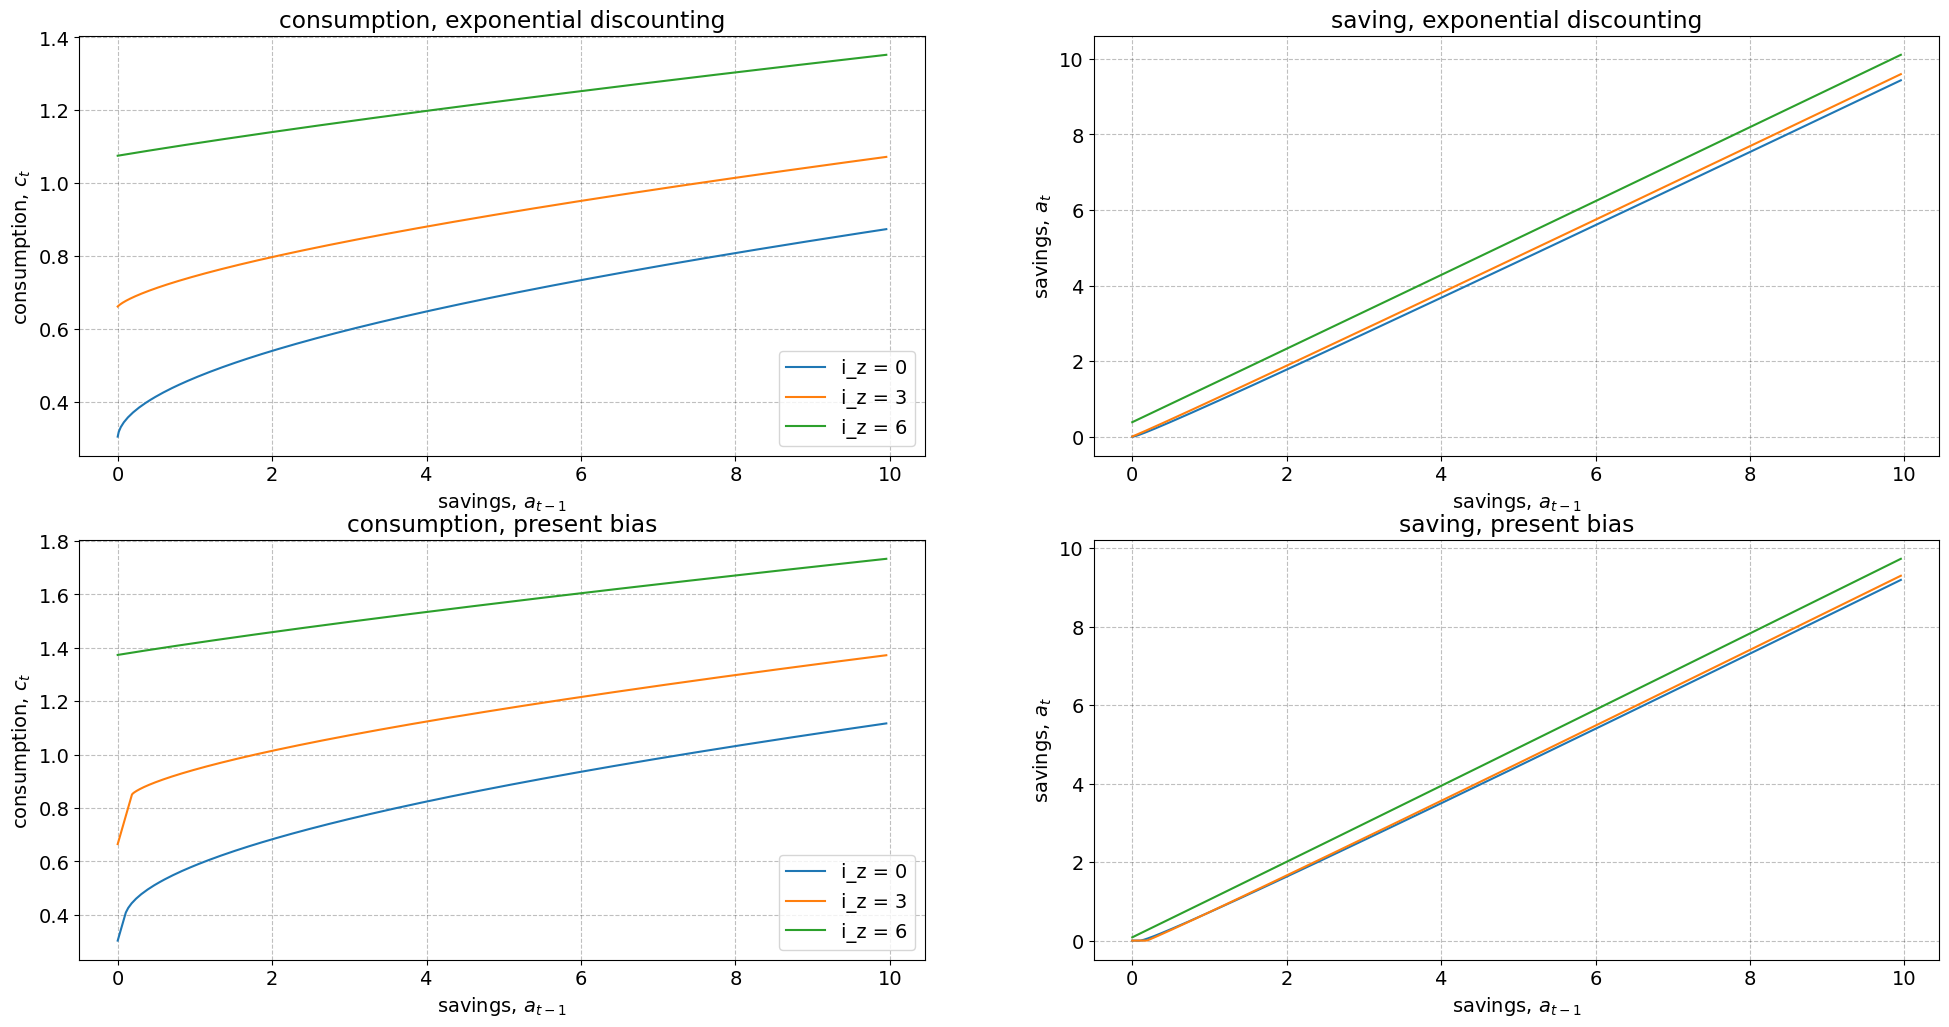

In [94]:
fig = plt.figure(figsize=(24,12),dpi=100)
a_max = 10

# a. consumption, without present bias
I = PB.par.a_grid < a_max

ax = fig.add_subplot(2,2,1)
ax.set_title(f'consumption, exponential discounting')


for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(PB.par.a_grid[I],PB.ss.c[0,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# b. saving, without present bias
I = PB.par.a_grid < a_max

ax = fig.add_subplot(2,2,2)
ax.set_title(f'saving, exponential discounting')

for i_z in [0,PB.par.Nz//2,PB.par.Nz-1]:
    ax.plot(PB.par.a_grid[I],PB.ss.a[0,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')

# c. consumption, with present bias
I = PB.par.a_grid < a_max

ax = fig.add_subplot(2,2,3)
ax.set_title(f'consumption, present bias')

for i_z in [0,PB.par.Nz//2,PB.par.Nz-1]:
    ax.plot(PB.par.a_grid[I],PB.ss.c[1,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# d. saving, with present bias
I = PB.par.a_grid < a_max

ax = fig.add_subplot(2,2,4)
ax.set_title(f'saving, present bias')

for i_z in [0,PB.par.Nz//2,par.Nz-1]:
    ax.plot(PB.par.a_grid[I],PB.ss.a[1,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')


plt.show()

## 3. <a id='toc3_'></a>[Foreign demand shock](#toc0_)

In [ ]:
par.jump_M_s = -0.0075 # initial jump
par.rho_M_s = 0.80 # AR(1) coefficeint

par.jump_rF = -0.00005 # initial jump
par.rho_rF = 0.80 # AR(1) coefficeint

par.jump_PF_s = -0.03 # initial jump
par.rho_PF_s = 0.80 # AR(1) coefficeint

model.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=True,do_end_check=False)

In [ ]:
paths = ['GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock']
model.show_IRFs(paths,lvl_value=lvl_value,T_max=48,ncols=3)

In [ ]:
model.show_IRFs(['NFA','Q','E'],lvl_value=lvl_value,T_max=500,ncols=3,do_shocks=False,do_targets=False)

Without present bias:

In [ ]:
ExpoDisc = model.copy()
ExpoDisc.par.delta = 1.0

ExpoDisc.find_ss(do_print=True)
ExpoDisc.compute_jacs(do_print=True)

ExpoDisc.par.jump_M_s = -0.0075 # initial jump
ExpoDisc.par.rho_M_s = 0.80 # AR(1) coefficeint

ExpoDisc.par.jump_rF = -0.00005 # initial jump
ExpoDisc.par.rho_rF = 0.80 # AR(1) coefficeint

ExpoDisc.par.jump_PF_s = -0.03 # initial jump
ExpoDisc.par.rho_PF_s = 0.80 # AR(1) coefficeint

ExpoDisc.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=True,do_end_check=False)

In [ ]:
MPC = np.sum(ExpoDisc.ss.D[:,:,:-1]*(ExpoDisc.ss.c[:,:,1:]-ExpoDisc.ss.c[:,:,:-1])/((1+ExpoDisc.ss.r)*(ExpoDisc.par.a_grid[1:]-ExpoDisc.par.a_grid[:-1])))
print(f'{MPC:.2f}')

In [ ]:
PBsmall = model.copy()
PBsmall.par.delta = 0.9

PBsmall.find_ss(do_print=True)
PBsmall.compute_jacs(do_print=True)

PBsmall.par.jump_M_s = -0.0075 # initial jump
PBsmall.par.rho_M_s = 0.80 # AR(1) coefficeint

PBsmall.par.jump_rF = -0.00005 # initial jump
PBsmall.par.rho_rF = 0.80 # AR(1) coefficeint

PBsmall.par.jump_PF_s = -0.03 # initial jump
PBsmall.par.rho_PF_s = 0.80 # AR(1) coefficeint

PBsmall.find_transition_path(shocks=['M_s','rF','PF_s'],do_print=True,do_end_check=False)

In [ ]:
MPC = np.sum(PBsmall.ss.D[:,:,:-1]*(PBsmall.ss.c[:,:,1:]-PBsmall.ss.c[:,:,:-1])/((1+PBsmall.ss.r)*(PBsmall.par.a_grid[1:]-PBsmall.par.a_grid[:-1])))
print(f'{MPC:.2f}')

In [ ]:
models = [model,PBsmall,ExpoDisc]
labels = ['$\delta = 0.6$','$\delta = 0.9 $','$\delta = 1.0 $']
model.compare_IRFs(models,labels,varnames=['M_s','beta','G','i_shock','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 4. <a id='toc4_'></a>[Response in consumption Goverment Spending Shock](#toc0_)

In [ ]:
model.par.jump_G = -0.025
model.par.rho_G = 0.80 # AR(1) coefficeint

model.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

ExpoDisc.par.jump_G = -0.025
ExpoDisc.par.rho_G = 0.80 # AR(1) coefficeint

ExpoDisc.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

PBsmall.par.jump_G = -0.025
PBsmall.par.rho_G = 0.80 # AR(1) coefficeint

PBsmall.find_transition_path(shocks=['G'],do_print=True,do_end_check=False)

In [ ]:
models = [model,PBsmall,ExpoDisc]
labels = ['$\delta = 0.6$','$\delta = 0.9 $','$\delta = 1.0 $']
model.compare_IRFs(models,labels,varnames=['G','GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)